In [57]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# --- find repo root by walking up until we see both "data/" and "reports/" ---
cwd = Path.cwd()
root = None
for p in [cwd] + list(cwd.parents):
    if (p / "data").exists() and (p / "reports").exists():
        root = p
        break

# fallback: only require "data/" (in case reports isn't in repo root yet)
if root is None:
    for p in [cwd] + list(cwd.parents):
        if (p / "data").exists():
            root = p
            break

if root is None:
    raise FileNotFoundError(f"Could not locate repo root from cwd={cwd}")

print("Repo root:", root)

# --- locate TSV robustly ---
preferred = root / "reports" / "eval_final_all_t0p5.tsv"
if preferred.exists():
    tsv = preferred
else:
    # search anywhere under repo (in case it's in a different path)
    hits = list(root.rglob("eval_final_all_t0p5.tsv"))
    if not hits:
        raise FileNotFoundError(f"Could not find eval_final_all_t0p5.tsv under {root}")
    tsv = hits[0]

print("Loading TSV:", tsv)

df = pd.read_csv(tsv, sep="\t")
df["model"] = df["model"].astype(str).str.upper()

for c in ["reads_in","reads_out","pct_kept","spades_contigs","spades_total_len","spades_max_len"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df.head()

Repo root: /Users/yvonnelin/Desktop/mitochime
Loading TSV: /Users/yvonnelin/Desktop/mitochime/reports/eval_final_all_t0p5.tsv


,dataset,model,thresh,reads_in,reads_out,pct_kept,spades_contigs,spades_total_len,spades_max_len,contigs_path
0,10K_final_5,UNFILTERED,NaN,10000,10000,100.00,1,16615,16615,data/assemblies_spades/10K_final_5_unfiltered/...
1,10K_final_5,GB,0.5,10000,9732,97.32,1,16615,16615,data/assemblies_spades/10K_final_5_gb_t0p5/spa...
2,10K_final_5,CNN,0.5,10000,8314,83.14,1,16599,16599,data/assemblies_spades/10K_final_5_cnn_t0p5/sp...
3,10K_final_10,UNFILTERED,NaN,10000,10000,100.00,1,16704,16704,data/assemblies_spades/10K_final_10_unfiltered...
4,10K_final_10,GB,0.5,10000,9530,95.30,1,16614,16614,data/assemblies_spades/10K_final_10_gb_t0p5/sp...


In [58]:
def parse_read_level(s: str):
    m = re.match(r"^(3200|10K|20K)", str(s))
    return m.group(1) if m else None

def parse_chimera_pct(s: str):
    m = re.search(r"_final_(\d+)", str(s))
    return int(m.group(1)) if m else None

df["read_level"] = df["dataset"].apply(parse_read_level)
df["chimera_pct"] = df["dataset"].apply(parse_chimera_pct)

order = ["3200","10K","20K"]
df["read_level"] = pd.Categorical(df["read_level"], order, ordered=True)

df[["dataset","read_level","chimera_pct","model","thresh","pct_kept"]].sort_values(
    ["read_level","chimera_pct","model"]
).head(15)

,dataset,read_level,chimera_pct,model,thresh,pct_kept
26,3200_final_5,3200,5,CNN,0.5,84.000
25,3200_final_5,3200,5,GB,0.5,97.406
24,3200_final_5,3200,5,UNFILTERED,NaN,100.000
29,3200_final_10,3200,10,CNN,0.5,79.938
28,3200_final_10,3200,10,GB,0.5,95.219
27,3200_final_10,3200,10,UNFILTERED,NaN,100.000
32,3200_final_15,3200,15,CNN,0.5,75.812
31,3200_final_15,3200,15,GB,0.5,93.375
30,3200_final_15,3200,15,UNFILTERED,NaN,100.000
35,3200_final_50,3200,50,CNN,0.5,50.719


In [59]:
def contigs_to_gfa(contigs_path: str) -> Path:
    p = Path(contigs_path)
    return p.parent / "assembly_graph.gfa"

def gfa_metrics(gfa_path: Path):
    """
    nodes = #segments (S lines)
    links = #links (L lines)
    components = connected components (undirected)
    """
    segs = set()
    edges = []
    nS = nL = 0

    with gfa_path.open("rt") as f:
        for line in f:
            if not line or line[0] == "#":
                continue
            if line.startswith("S\t"):
                parts = line.rstrip("\n").split("\t")
                segs.add(parts[1]); nS += 1
            elif line.startswith("L\t"):
                parts = line.rstrip("\n").split("\t")
                u, v = parts[1], parts[3]
                edges.append((u, v)); nL += 1

    # union-find
    parent = {x: x for x in segs}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for u, v in edges:
        if u in parent and v in parent:
            union(u, v)

    comps = {find(x) for x in segs} if segs else set()
    return nS, nL, len(comps)

gfa_nodes, gfa_links, gfa_components, gfa_paths = [], [], [], []

for cp in df["contigs_path"].astype(str):
    gp = contigs_to_gfa(cp)
    gfa_paths.append(str(gp))
    if gp.exists():
        nS, nL, nC = gfa_metrics(gp)
    else:
        nS, nL, nC = (np.nan, np.nan, np.nan)
    gfa_nodes.append(nS); gfa_links.append(nL); gfa_components.append(nC)

df["gfa_path"] = gfa_paths
df["gfa_nodes"] = gfa_nodes
df["gfa_links"] = gfa_links
df["gfa_components"] = gfa_components

df[["dataset","model","spades_contigs","spades_max_len","gfa_nodes","gfa_components"]].head(10)

,dataset,model,spades_contigs,spades_max_len,gfa_nodes,gfa_components
0,10K_final_5,UNFILTERED,1,16615,NaN,NaN
1,10K_final_5,GB,1,16615,NaN,NaN
2,10K_final_5,CNN,1,16599,NaN,NaN
3,10K_final_10,UNFILTERED,1,16704,NaN,NaN
4,10K_final_10,GB,1,16614,NaN,NaN
5,10K_final_10,CNN,1,16614,NaN,NaN
6,10K_final_15,UNFILTERED,1,16735,NaN,NaN
7,10K_final_15,GB,1,16642,NaN,NaN
8,10K_final_15,CNN,1,16611,NaN,NaN
9,10K_final_50,UNFILTERED,1,16715,NaN,NaN


In [60]:
final_cols = [
    "read_level","chimera_pct","dataset","model","thresh",
    "reads_in","reads_out","pct_kept",
    "spades_contigs","spades_total_len","spades_max_len",
    "gfa_components","gfa_nodes","gfa_links",
    "contigs_path","gfa_path"
]

final_tbl = df[final_cols].sort_values(["read_level","chimera_pct","model"])
final_tbl

,read_level,chimera_pct,dataset,model,thresh,reads_in,reads_out,pct_kept,spades_contigs,spades_total_len,spades_max_len,gfa_components,gfa_nodes,gfa_links,contigs_path,gfa_path
26,3200,5,3200_final_5,CNN,0.5,3200,2688,84.000,1,16352,16352,NaN,NaN,NaN,data/assemblies_spades/3200_final_5_cnn_t0p5/s...,data/assemblies_spades/3200_final_5_cnn_t0p5/s...
25,3200,5,3200_final_5,GB,0.5,3200,3117,97.406,1,16577,16577,NaN,NaN,NaN,data/assemblies_spades/3200_final_5_gb_t0p5/sp...,data/assemblies_spades/3200_final_5_gb_t0p5/sp...
24,3200,5,3200_final_5,UNFILTERED,NaN,3200,3200,100.000,1,16599,16599,NaN,NaN,NaN,data/assemblies_spades/3200_final_5_unfiltered...,data/assemblies_spades/3200_final_5_unfiltered...
29,3200,10,3200_final_10,CNN,0.5,3200,2558,79.938,1,16584,16584,NaN,NaN,NaN,data/assemblies_spades/3200_final_10_cnn_t0p5/...,data/assemblies_spades/3200_final_10_cnn_t0p5/...
28,3200,10,3200_final_10,GB,0.5,3200,3047,95.219,1,16615,16615,NaN,NaN,NaN,data/assemblies_spades/3200_final_10_gb_t0p5/s...,data/assemblies_spades/3200_final_10_gb_t0p5/s...
27,3200,10,3200_final_10,UNFILTERED,NaN,3200,3200,100.000,1,16591,16591,NaN,NaN,NaN,data/assemblies_spades/3200_final_10_unfiltere...,data/assemblies_spades/3200_final_10_unfiltere...
32,3200,15,3200_final_15,CNN,0.5,3200,2426,75.812,2,16438,14906,NaN,NaN,NaN,data/assemblies_spades/3200_final_15_cnn_t0p5/...,data/assemblies_spades/3200_final_15_cnn_t0p5/...
31,3200,15,3200_final_15,GB,0.5,3200,2988,93.375,1,16606,16606,NaN,NaN,NaN,data/assemblies_spades/3200_final_15_gb_t0p5/s...,data/assemblies_spades/3200_final_15_gb_t0p5/s...
30,3200,15,3200_final_15,UNFILTERED,NaN,3200,3200,100.000,1,16645,16645,NaN,NaN,NaN,data/assemblies_spades/3200_final_15_unfiltere...,data/assemblies_spades/3200_final_15_unfiltere...
35,3200,50,3200_final_50,CNN,0.5,3200,1623,50.719,2,16714,16427,NaN,NaN,NaN,data/assemblies_spades/3200_final_50_cnn_t0p5/...,data/assemblies_spades/3200_final_50_cnn_t0p5/...


In [61]:
base = (df[df["model"]=="UNFILTERED"]
        .set_index("dataset")[[
            "spades_contigs","spades_total_len","spades_max_len",
            "gfa_components","gfa_nodes","gfa_links"
        ]]
        .rename(columns=lambda c: "unf_" + c)
)

dfd = df.join(base, on="dataset")

dfd["delta_contigs"] = dfd["spades_contigs"] - dfd["unf_spades_contigs"]
dfd["delta_total_len"] = dfd["spades_total_len"] - dfd["unf_spades_total_len"]
dfd["delta_max_len"] = dfd["spades_max_len"] - dfd["unf_spades_max_len"]
dfd["delta_components"] = dfd["gfa_components"] - dfd["unf_gfa_components"]
dfd["delta_nodes"] = dfd["gfa_nodes"] - dfd["unf_gfa_nodes"]

delta_tbl = dfd[dfd["model"].isin(["GB","CNN"])][[
    "read_level","chimera_pct","dataset","model","thresh","pct_kept",
    "delta_components","delta_nodes","delta_contigs","delta_max_len","delta_total_len"
]].sort_values(["read_level","chimera_pct","model"])

delta_tbl

,read_level,chimera_pct,dataset,model,thresh,pct_kept,delta_components,delta_nodes,delta_contigs,delta_max_len,delta_total_len
26,3200,5,3200_final_5,CNN,0.5,84.000,NaN,NaN,0,-247,-247
25,3200,5,3200_final_5,GB,0.5,97.406,NaN,NaN,0,-22,-22
29,3200,10,3200_final_10,CNN,0.5,79.938,NaN,NaN,0,-7,-7
28,3200,10,3200_final_10,GB,0.5,95.219,NaN,NaN,0,24,24
32,3200,15,3200_final_15,CNN,0.5,75.812,NaN,NaN,1,-1739,-207
31,3200,15,3200_final_15,GB,0.5,93.375,NaN,NaN,0,-39,-39
35,3200,50,3200_final_50,CNN,0.5,50.719,NaN,NaN,1,-309,-22
34,3200,50,3200_final_50,GB,0.5,77.875,NaN,NaN,0,-90,-90
2,10K,5,10K_final_5,CNN,0.5,83.140,NaN,NaN,0,-16,-16
1,10K,5,10K_final_5,GB,0.5,97.320,NaN,NaN,0,0,0


In [62]:
cand = dfd[dfd["model"].isin(["GB","CNN"])].copy()

best = (cand.sort_values(
            ["dataset","gfa_components","gfa_nodes","spades_contigs","spades_max_len","pct_kept"],
            ascending=[True,True,True,True,False,False]
        )
        .groupby("dataset", as_index=False)
        .head(1)
        .sort_values(["read_level","chimera_pct"])
)

best[[
    "read_level","chimera_pct","dataset","model","thresh","pct_kept",
    "spades_contigs","spades_max_len","gfa_components","gfa_nodes",
    "delta_components","delta_nodes","delta_contigs","delta_max_len"
]]

,read_level,chimera_pct,dataset,model,thresh,pct_kept,spades_contigs,spades_max_len,gfa_components,gfa_nodes,delta_components,delta_nodes,delta_contigs,delta_max_len
25,3200,5,3200_final_5,GB,0.5,97.406,1,16577,NaN,NaN,NaN,NaN,0,-22
28,3200,10,3200_final_10,GB,0.5,95.219,1,16615,NaN,NaN,NaN,NaN,0,24
31,3200,15,3200_final_15,GB,0.5,93.375,1,16606,NaN,NaN,NaN,NaN,0,-39
34,3200,50,3200_final_50,GB,0.5,77.875,1,16646,NaN,NaN,NaN,NaN,0,-90
1,10K,5,10K_final_5,GB,0.5,97.320,1,16615,NaN,NaN,NaN,NaN,0,0
4,10K,10,10K_final_10,GB,0.5,95.300,1,16614,NaN,NaN,NaN,NaN,0,-90
7,10K,15,10K_final_15,GB,0.5,93.330,1,16642,NaN,NaN,NaN,NaN,0,-93
10,10K,50,10K_final_50,GB,0.5,78.940,1,16787,NaN,NaN,NaN,NaN,0,72
14,20K,5,20K_final_5,CNN,0.5,83.685,1,16669,NaN,NaN,NaN,NaN,0,0
17,20K,10,20K_final_10,CNN,0.5,79.940,1,16770,NaN,NaN,NaN,NaN,0,-29


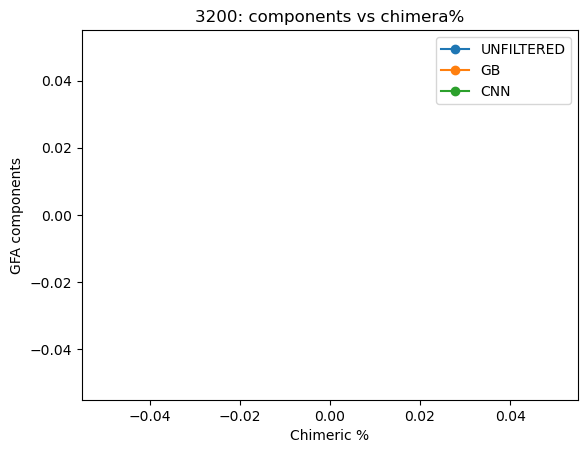

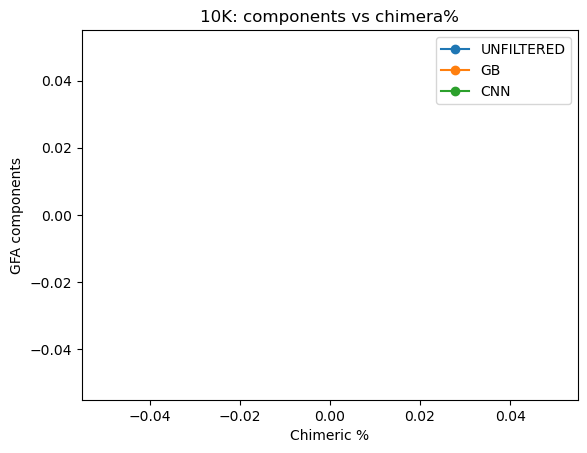

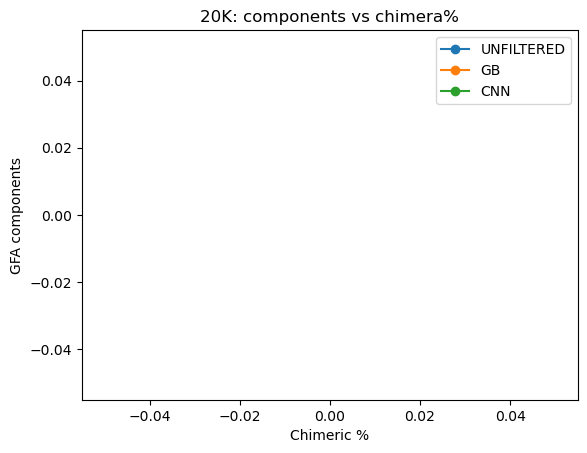

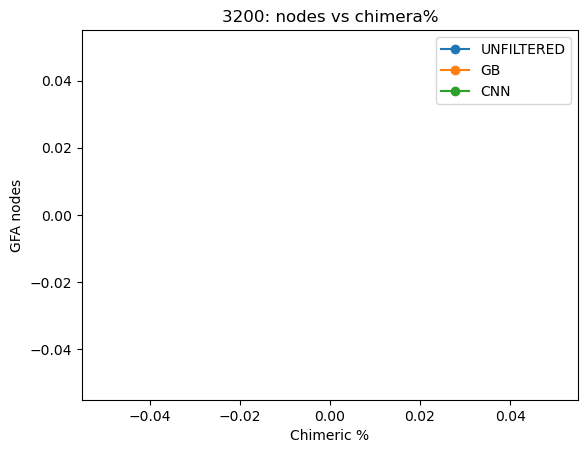

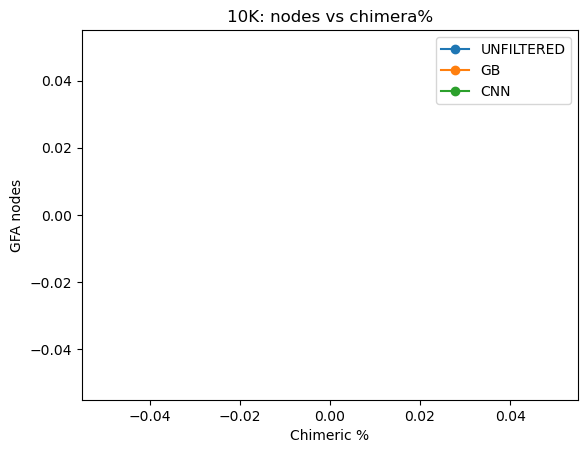

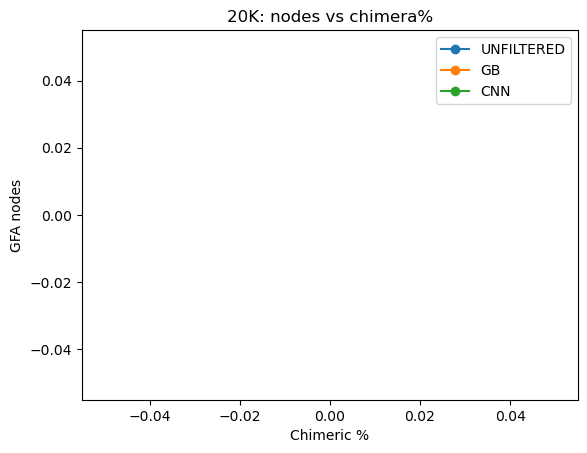

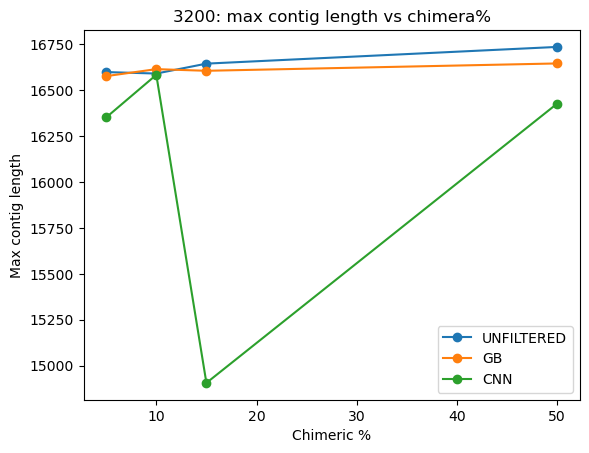

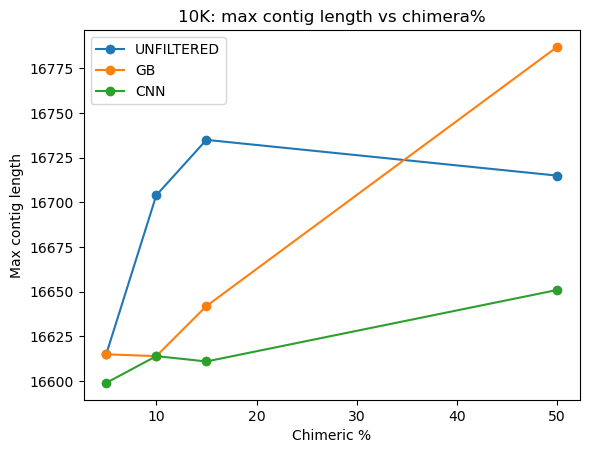

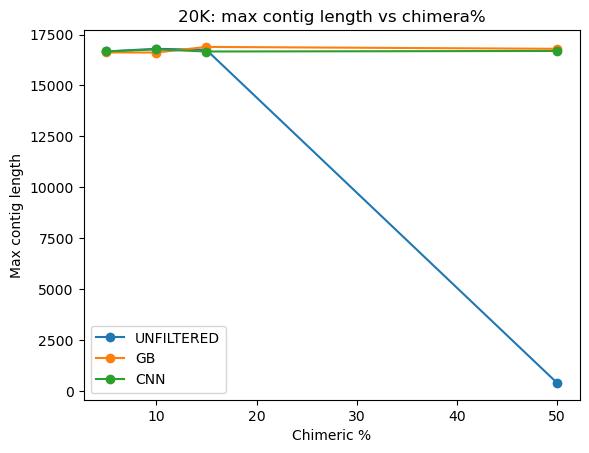

In [63]:
plot_df = dfd[dfd["model"].isin(["UNFILTERED","GB","CNN"])].copy()

def plot_metric(metric, ylabel, title_suffix):
    for rl in ["3200","10K","20K"]:
        d = plot_df[plot_df["read_level"]==rl].sort_values("chimera_pct")
        if d.empty:
            continue
        plt.figure()
        for m in ["UNFILTERED","GB","CNN"]:
            dm = d[d["model"]==m]
            plt.plot(dm["chimera_pct"], dm[metric], marker="o", label=m)
        plt.xlabel("Chimeric %")
        plt.ylabel(ylabel)
        plt.title(f"{rl}: {title_suffix}")
        plt.legend()
        plt.show()

plot_metric("gfa_components", "GFA components", "components vs chimera%")
plot_metric("gfa_nodes", "GFA nodes", "nodes vs chimera%")
plot_metric("spades_max_len", "Max contig length", "max contig length vs chimera%")

In [64]:
out_dir = root / "reports"
final_tbl.to_csv(out_dir / "final_metrics_with_nodes.tsv", sep="\t", index=False)
delta_tbl.to_csv(out_dir / "final_deltas_vs_unfiltered.tsv", sep="\t", index=False)
best.to_csv(out_dir / "final_best_per_dataset.tsv", sep="\t", index=False)

print("Wrote:")
print("-", out_dir / "final_metrics_with_nodes.tsv")
print("-", out_dir / "final_deltas_vs_unfiltered.tsv")
print("-", out_dir / "final_best_per_dataset.tsv")

Wrote:
- /Users/yvonnelin/Desktop/mitochime/reports/final_metrics_with_nodes.tsv
- /Users/yvonnelin/Desktop/mitochime/reports/final_deltas_vs_unfiltered.tsv
- /Users/yvonnelin/Desktop/mitochime/reports/final_best_per_dataset.tsv
